# Downloading the data and computing log-returns

In [1]:
# Requirements:
#   pip install yfinance pandas numpy matplotlib statsmodels scipy
#

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm, probplot

# ----------------------------
# 1) Download Apple data
# ----------------------------
ticker = "AAPL"
start_date = "2020-01-01"
end_date   = "2025-12-31"


df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust= False,
)

# ---- FIX: flatten columns if MultiIndex ----
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep Close prices
df = df.dropna(subset=["Close"])
price = df["Close"].astype(float)

#  Log-returns

log_ret = np.log(price).diff().dropna()


# Log-Returns + Histogram + Volatility

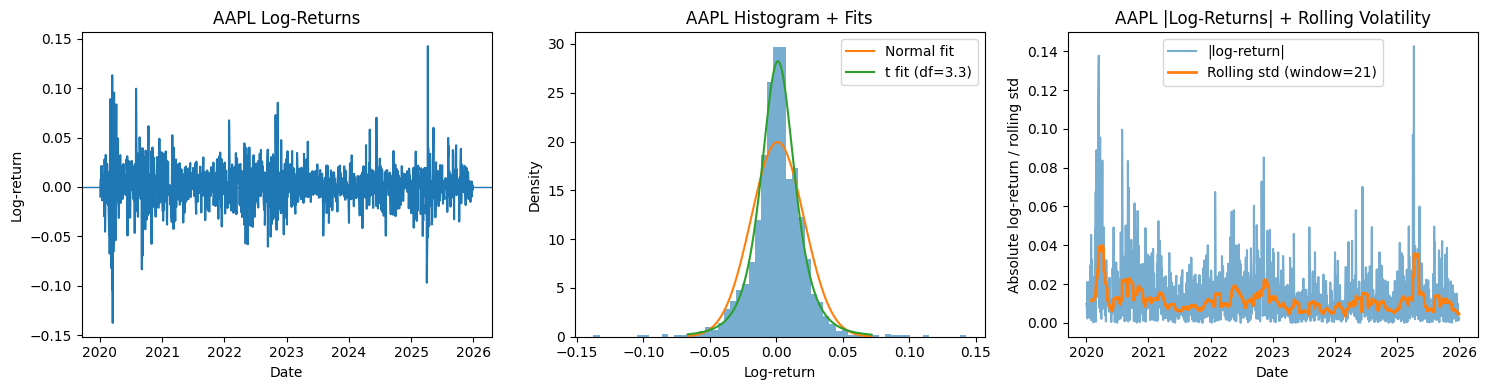

In [2]:
from scipy.stats import norm, t
import numpy as np
import matplotlib.pyplot as plt

# 1) Fit Normal
mu_hat, sigma_hat = np.mean(log_ret), np.std(log_ret, ddof=1)

# 2) Fit Student-t (df, loc, scale)
df_t, loc_t, scale_t = t.fit(log_ret)

# 3) Rolling volatility (std) on absolute returns
abs_ret = log_ret.abs()

# choose a window (e.g. ~1 trading month). Change if you want.
window = 21
roll_std = abs_ret.rolling(window=window).std()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (A) Time series of log-returns
axes[0].plot(log_ret.index, log_ret.values)
axes[0].axhline(0, linewidth=1)
axes[0].set_title(f"{ticker} Log-Returns")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Log-return")

# (B) Histogram + fitted PDFs
axes[1].hist(log_ret, bins=60, density=True, alpha=0.6)
xmin, xmax = np.percentile(log_ret, [0.5, 99.5])
grid = np.linspace(xmin, xmax, 500)

axes[1].plot(grid, norm.pdf(grid, loc=mu_hat, scale=sigma_hat), label="Normal fit")
axes[1].plot(grid, t.pdf(grid, df=df_t, loc=loc_t, scale=scale_t), label=f"t fit (df={df_t:.1f})")

axes[1].set_title(f"{ticker} Histogram + Fits")
axes[1].set_xlabel("Log-return")
axes[1].set_ylabel("Density")
axes[1].legend()

# (C) Absolute returns + rolling std
axes[2].plot(abs_ret.index, abs_ret.values, alpha=0.6, label="|log-return|")
axes[2].plot(roll_std.index, roll_std.values, linewidth=2, label=f"Rolling std (window={window})")
axes[2].set_title(f"{ticker} |Log-Returns| + Rolling Volatility")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Absolute log-return / rolling std")
axes[2].legend()

plt.tight_layout()
plt.savefig("hist_apple_1x3.png", dpi=200)
plt.show()



# Fitting AR(1) Model

In [ ]:
!pip install arch

In [8]:
from arch import arch_model
# ---- AR(1) with constant variance ----
model = arch_model(
    100*log_ret,
    mean="AR",
    lags=1,
    vol="Constant",
    dist="t"
)
res = model.fit(disp="off")


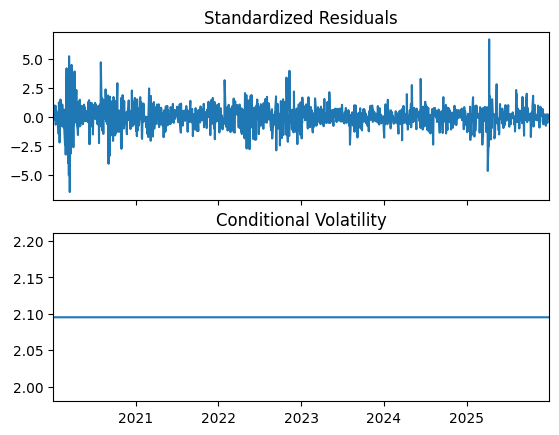

In [9]:
res.plot()
plt.show()

# Fitting AR(1) + ARCH(1) Model

In [13]:
model_arch1 = arch_model(
    100*log_ret,
    mean="AR",
    lags=1,
    vol="ARCH",
    p=1,
    dist="t"
)
res_arch1 = model_arch1.fit(disp="off")
print(res_arch1.summary())

                              AR - ARCH Model Results                               
Dep. Variable:                        Close   R-squared:                      -0.000
Mean Model:                              AR   Adj. R-squared:                 -0.001
Vol Model:                             ARCH   Log-Likelihood:               -2995.97
Distribution:      Standardized Student's t   AIC:                           6001.94
Method:                  Maximum Likelihood   BIC:                           6028.52
                                              No. Observations:                 1505
Date:                      Mon, Feb 09 2026   Df Residuals:                     1503
Time:                              14:06:58   Df Model:                            2
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------

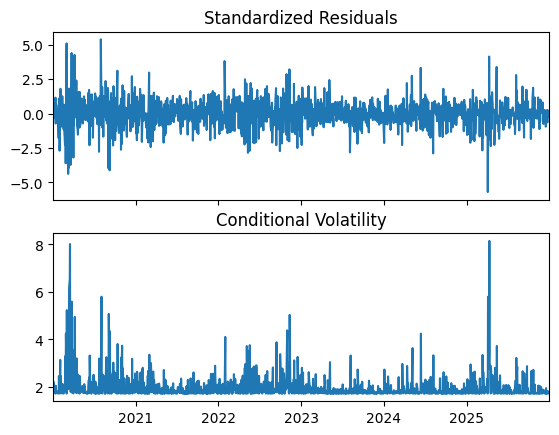

In [14]:
res_arch1.plot()
plt.show()

# Fitting Various AR + ARCH

In [17]:
import pandas as pd
results = []
for p in range(8):  # AR lags from 0 to 7
    for q in range(1,8):  # ARCH lags from 0 to 7
        try:
            model = arch_model(100*log_ret, mean='AR', lags=p, vol='ARCH', p=q, dist='t')
            result = model.fit(disp='off')
            bic = result.bic
            results.append((p, q, bic))
            print(f"AR({p}) + ARCH({q}) - BIC: {bic:.2f}")
        except Exception as e:
            print(f"AR({p}) + ARCH({q}) failed: {e}")

# Step 3: Find the best combination based on BIC
results_df = pd.DataFrame(results, columns=['AR_Lags', 'ARCH_Lags', 'BIC'])
best_model = results_df.loc[results_df['BIC'].idxmin()]

# Print the best model
print("\nBest Model:")
print(f"AR({int(best_model['AR_Lags'])}) + ARCH({int(best_model['ARCH_Lags'])}) - BIC: {best_model['BIC']:.2f}")

# Step 4: Fit the best model
p_best, q_best = int(best_model['AR_Lags']), int(best_model['ARCH_Lags'])
final_model = arch_model(100*log_ret, mean='AR', lags=p_best, vol='ARCH', p=q_best, dist='t')
final_result = final_model.fit(disp='off')

# Print the final model summary
print("\nFinal Model Summary:")
print(final_result.summary())

AR(0) + ARCH(1) - BIC: 6024.37
AR(0) + ARCH(2) - BIC: 5999.15
AR(0) + ARCH(3) - BIC: 5996.26
AR(0) + ARCH(4) - BIC: 5982.43
AR(0) + ARCH(5) - BIC: 5973.45
AR(0) + ARCH(6) - BIC: 5971.54
AR(0) + ARCH(7) - BIC: 5977.21
AR(1) + ARCH(1) - BIC: 6028.52
AR(1) + ARCH(2) - BIC: 6003.42
AR(1) + ARCH(3) - BIC: 6000.26
AR(1) + ARCH(4) - BIC: 5986.01
AR(1) + ARCH(5) - BIC: 5977.56
AR(1) + ARCH(6) - BIC: 5975.43
AR(1) + ARCH(7) - BIC: 5981.06
AR(2) + ARCH(1) - BIC: 6033.12
AR(2) + ARCH(2) - BIC: 6007.70
AR(2) + ARCH(3) - BIC: 6004.08
AR(2) + ARCH(4) - BIC: 5990.11
AR(2) + ARCH(5) - BIC: 5981.63
AR(2) + ARCH(6) - BIC: 5979.56
AR(2) + ARCH(7) - BIC: 5985.25
AR(3) + ARCH(1) - BIC: 6036.53
AR(3) + ARCH(2) - BIC: 6011.23
AR(3) + ARCH(3) - BIC: 6008.06
AR(3) + ARCH(4) - BIC: 5993.34
AR(3) + ARCH(5) - BIC: 5984.88
AR(3) + ARCH(6) - BIC: 5982.53
AR(3) + ARCH(7) - BIC: 5988.29
AR(4) + ARCH(1) - BIC: 6039.73
AR(4) + ARCH(2) - BIC: 6014.76
AR(4) + ARCH(3) - BIC: 6011.43
AR(4) + ARCH(4) - BIC: 5996.66
AR(4) + 

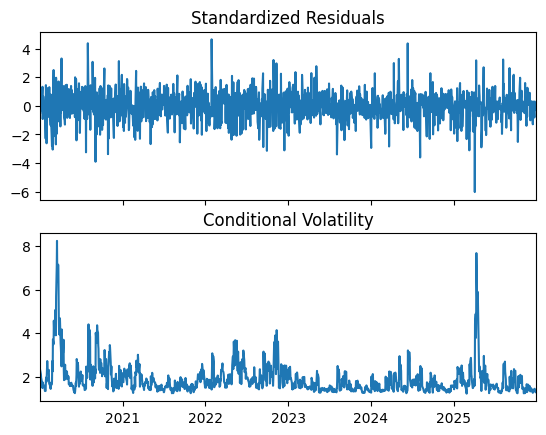

In [18]:
final_result.plot()
plt.show()